In [173]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ICA Related Components
import mne 
from mne.preprocessing import (ICA, 
                              create_ecg_epochs, 
                              create_eog_epochs)

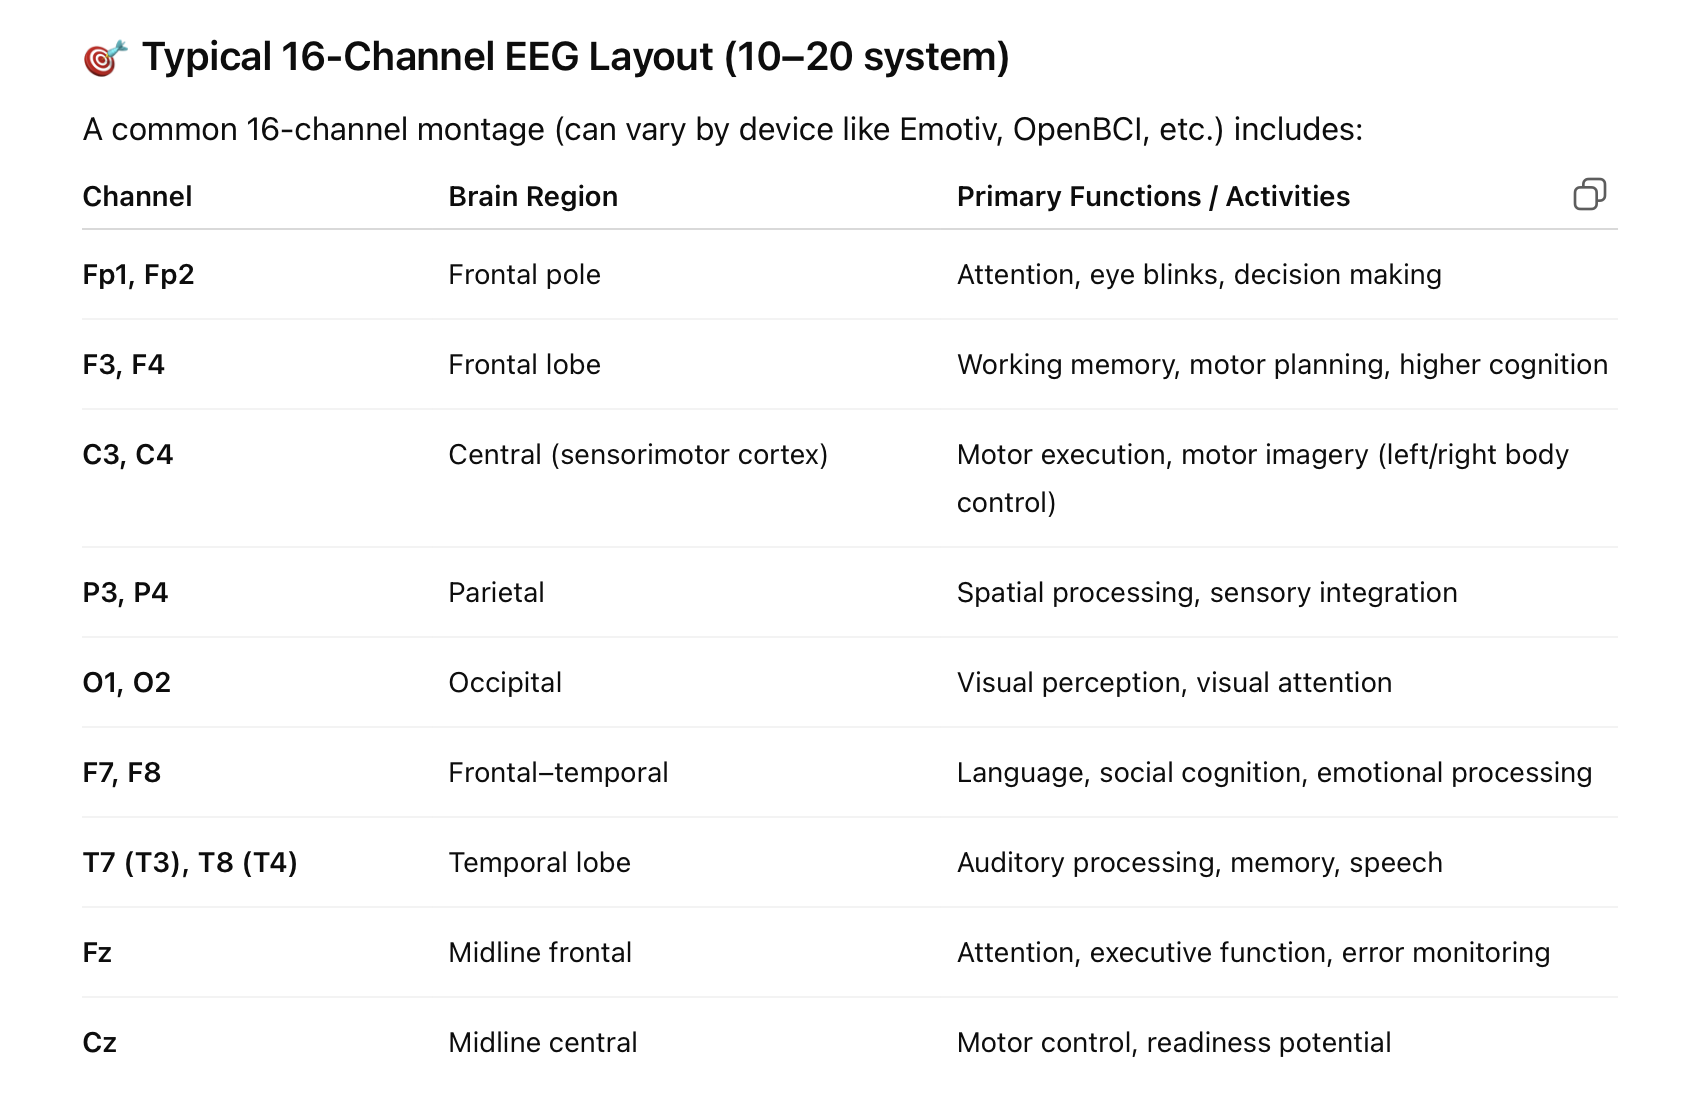

# Load EEG Data

In [174]:
data = np.load("../eeg_processed/eeg_data.npz")
X_main, y = data['X'], data['y']
print(f"X (n_trails, n_channels, n_samples) : {X_main.shape}")
print(f"y (n_trails, ) : {y.shape}")

X (n_trails, n_channels, n_samples) : (1799, 16, 500)
y (n_trails, ) : (1799,)


# Perform ICA on EEG Dataset

In [175]:
n_trails, n_channels, n_samples = X.shape[0], X.shape[1], X.shape[2]
sfreq = 125 # Sampling frequency in HZ

ch_names = ["FT8", "F3", "Fz", "F4", "FC5", "FC1", "FC2", "Cz",
            "T3", "CP5", "C3", "CP1", "CP2", "C4", "CP6", "T4"]
ch_types = ['eeg'] * n_channels
print(f"Channel Names : {ch_names} and\n Channel Types : {ch_types}")


# Load standard 10-20 montage
montage = mne.channels.make_standard_montage("standard_1020")
# Select the OpenBCI 16-channel subset
openbci_chs = ["Fp1","Fp2","C3","C4","P7","P8","O1","O2",
               "F7","F8","F3","F4","P3","P4","T7","T8"]
openbci_chs = ["FT8", "F3", "Fz", "F4", "FC5", "FC1", "FC2", "Cz", "T3", "CP5", "C3", "CP1", "CP2", "C4", "CP6", "T4"]
electrode_positions = {}

for i in openbci_chs:
    electrode_positions[i] = montage.get_positions()["ch_pos"][i]    

# Create custom montage
custom_montage = mne.channels.make_dig_montage(
    ch_pos=electrode_positions,
    coord_frame="head"
)


Channel Names : ['FT8', 'F3', 'Fz', 'F4', 'FC5', 'FC1', 'FC2', 'Cz', 'T3', 'CP5', 'C3', 'CP1', 'CP2', 'C4', 'CP6', 'T4'] and
 Channel Types : ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']


In [176]:
custom_montage.get_positions()

{'ch_pos': OrderedDict([('FT8', array([ 0.0818151,  0.0154167, -0.01133  ])),
              ('F3', array([-0.0502438,  0.0531112,  0.042192 ])),
              ('Fz', array([0.0003122, 0.058512 , 0.066462 ])),
              ('F4', array([0.0518362, 0.0543048, 0.040814 ])),
              ('FC5', array([-0.0772149,  0.0186433,  0.02446  ])),
              ('FC1', array([-0.0340619,  0.0260111,  0.079987 ])),
              ('FC2', array([0.0347841, 0.0264379, 0.078808 ])),
              ('Cz', array([ 0.0004009, -0.009167 ,  0.100244 ])),
              ('T3', array([-0.0841611, -0.0160187, -0.009346 ])),
              ('CP5', array([-0.0795922, -0.0465507,  0.030949 ])),
              ('C3', array([-0.0653581, -0.0116317,  0.064358 ])),
              ('CP1', array([-0.0355131, -0.0472919,  0.091315 ])),
              ('CP2', array([ 0.0383838, -0.0470731,  0.090695 ])),
              ('C4', array([ 0.0671179, -0.0109003,  0.06358  ])),
              ('CP6', array([ 0.0833218, -0.0461013,  

#### 1. Shape Transformation

In [177]:
# To fit ICA we need the data in this format (n_channels, n_trails * n_samples)
# Current input shape looks like (n_trails, n_channels, n_samples)
try:
    assert((n_channels , n_trails * n_samples) == X.reshape(-1, 
            n_channels, 
            n_samples).transpose(1, 0, 2).reshape(n_channels, -1).shape)
    
    X_concated = X.reshape(-1, 
            n_channels, 
            n_samples).transpose(1, 0, 2).reshape(n_channels, -1)
    print("==== Success : Shape Transformation ====")
except:
    print("==== Failure : Shape Transformation ====")

==== Success : Shape Transformation ====


#### 2. Create MNE Raw Object

In [178]:
# mne metadata info
info = mne.create_info(ch_names = ch_names, 
                       sfreq=sfreq,
                       ch_types = ch_types)

# mne raw object
raw = mne.io.RawArray(data= X_concated, 
                      info= info)

raw.set_montage(custom_montage)

Creating RawArray with float64 data, n_channels=16, n_times=149500
    Range : 0 ... 149499 =      0.000 ...  1195.992 secs
Ready.


<RawArray | 16 x 149500 (1196.0 s), ~18.3 MB, data loaded>

#### 3. Preprocessing and Re-Referencing

In [179]:
# Band-pass filter 
raw.filter(l_freq= 1., h_freq = 40.)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (3.304 s)



[Parallel(n_jobs=1)]: Done  16 out of  16 | elapsed:    0.0s finished


<RawArray | 16 x 149500 (1196.0 s), ~18.3 MB, data loaded>

In [180]:
raw.set_eeg_reference("average")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawArray | 16 x 149500 (1196.0 s), ~18.3 MB, data loaded>

#### 4. ICA Decomposition

In [181]:
ica = ICA(n_components = n_channels -1, 
    random_state = 97, 
    method = "fastica")

# fit the data to raw
ica.fit(raw)

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 0.6s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,41 iterations on raw data (149500 samples)
ICA components,15
Available PCA components,16
Channel types,eeg
ICA components marked for exclusion,—


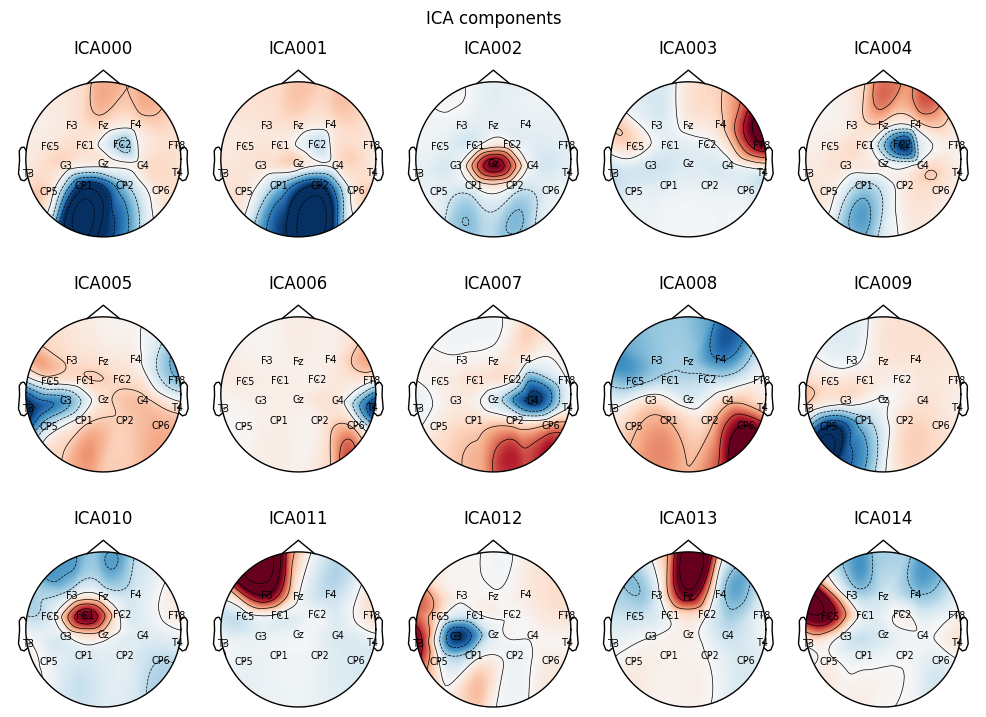

' Interpretation\n - Each electrode gets a weight (loading).\n - Positive values (usually in red) = electrodes where the IC contributes positively\n - Negative values (usually in blue) = electrodes where the IC contributed negatively\n\n Example:\n    Blink IC with positive spikes and frontal positivity\n    Blink IC with negative spike and frontal negativity\n\n    Here, Both mean the same thing\n'

In [182]:
# Plot ICA Components (topographic maps)
ica.plot_components(show_names=True, outlines = "head",) #colorbar=True
plt.show()


""" Interpretation
 - Each electrode gets a weight (loading).
 - Positive values (usually in red) = electrodes where the IC contributes positively
 - Negative values (usually in blue) = electrodes where the IC contributed negatively

 Example:
    Blink IC with positive spikes and frontal positivity
    Blink IC with negative spike and frontal negativity

    Here, Both mean the same thing
"""

In [197]:
ch_names[3]

'F4'

Using EOG channels: F3, Fz, F4
EOG channel index for this subject is: [1 2 3]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel F3 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1250 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 20 significant peaks
Number of EOG events detected: 20
Not setting metadata
20 matching events found
No baseline correction applied
Using data from preloaded Raw for 20 events and 125 original time points ...
0 bad epochs dropped
Applying baseline corre

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


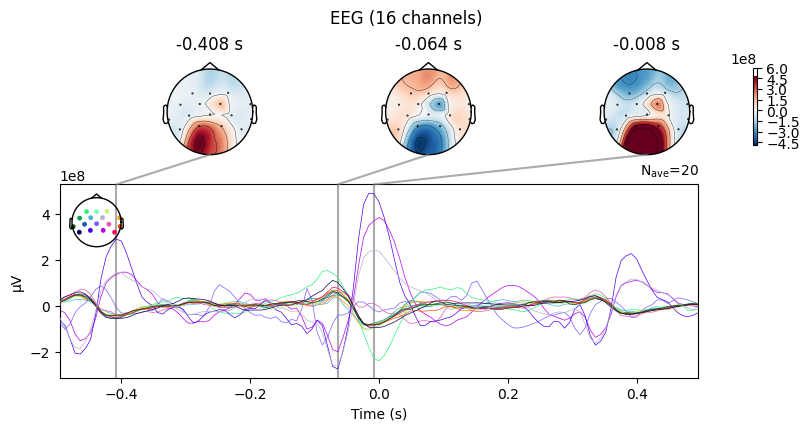

In [183]:
# Eye detection, blinks
eog_epochs = create_eog_epochs(raw, ch_name = [ch_names[1], 
                                           ch_names[2], 
                                           ch_names[3]],).average()
eog_epochs.apply_baseline(baseline=(None, -0.2))
eog_epochs.plot_joint()
plt.show()

In [195]:
eog_inds, scores = ica.find_bads_eog(raw, ch_name = ["F3", 
                                           "Fz", 
                                           "F4"])
print(eog_inds, scores)

Using EOG channels: F3, Fz, F4
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1250 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.2

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [193]:
ecg_inds, ecg_scores = ica.find_bads_ecg(raw,
                                         ch_name = ['T3'],
                                        method = "correlation",
                                        threshold = 2.0)


ValueError: ['T3'] not in channel list (['FT8', 'F3', 'Fz', 'F4', 'FC5', 'FC1', 'FC2', 'Cz', 'T3', 'CP5', 'C3', 'CP1', 'CP2', 'C4', 'CP6', 'T4'])